#  Iris 데이터셋으로 배우는 머신러닝 (기계학습) 입문

## 학습 목표
- 머신러닝의 기본 개념(지도학습, 분류)을 이해한다
- 데이터 탐색(EDA)의 중요성을 이해하고 직접 수행할 수 있다
- KNN 모델을 학습시키고 평가할 수 있다
- 정확도 평가 지표의 의미를 이해한다


# 머신러닝이란 무엇인가?

## 머신러닝(Machine Learning) 개요

> **머신러닝**이란 컴퓨터가 **데이터로부터 스스로 패턴을 학습**하여    
> 새로운 데이터에 대한 예측이나 결정을 내리는 기술입니다.

### 전통적 프로그래밍 vs 머신러닝

```
[전통적 프로그래밍]
데이터 + 규칙(코드) → 결과

[머신러닝]
데이터 + 결과(정답) → 규칙(모델)
```

### 머신러닝의 종류

| 종류 | 설명 | 예시 |
|------|------|------|
| **지도학습** | 정답(레이블)이 있는 데이터로 학습 | 스팸 메일 분류, 집값 예측 |
| **비지도학습** | 정답 없이 데이터의 패턴을 찾음 | 고객 세분화, 이상 탐지 |


### 지도학습 - 분류(Classification)

우리는 붓꽃(Iris) https://en.wikipedia.org/wiki/Iris_flower_data_set        
**꽃받침과 꽃잎의 크기**를 측정한 데이터를 이용해  
어떤 **품종**인지 맞추는 **분류 모델**을 만들 것입니다.

```
입력(X): 꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃잎 너비
출력(y): 품종 (0=Setosa, 1=Versicolor, 2=Virginica)
```


# 라이브러리 불러오기

| 라이브러리 | 용도 |
|-----------|------|
| `sklearn` | 머신러닝 알고리즘을 쉽게 사용할 수 있는 라이브러리 |

In [1]:
import pandas as pd           
import numpy as np            # 수치 계산
import matplotlib.pyplot as plt    
import seaborn as sns   

# 머신러닝 관련 모듈
from sklearn.model_selection import train_test_split   # 데이터 분할
from sklearn.neighbors import KNeighborsClassifier     # KNN 모델

# 그래프 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  

# 경고 메시지 숨기기 (깔끔한 출력을 위해)
import warnings
warnings.filterwarnings('ignore')

## 데이터 불러오기 및 기본 탐색 (EDA)

### EDA란?
> EDA(Exploratory Data Analysis, 탐색적 데이터 분석)란  
> 본격적인 분석 전에 데이터의 구조, 특성, 이상값 등을 파악하는 과정입니다.  
> 실제 데이터 과학 업무에서 전체 시간의 60~80% 를 차지할 만큼 중요합니다!

#### 데이터셋 소개: Iris(붓꽃) 데이터
- 1936년 통계학자 로널드 피셔가 수집한 유명한 데이터셋
- 3종류의 붓꽃(Setosa, Versicolor, Virginica) 각 50개씩, 총 **150개** 데이터
- 4개의 측정값(특성)으로 품종을 분류하는 것이 목표

In [2]:
df = pd.read_csv('iris.csv', encoding='cp949')

In [3]:
df

,꽃받침_길이,꽃받침_너비,꽃잎_길이,꽃잎_너비,품종
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   꽃받침_길이  150 non-null    float64
 1   꽃받침_너비  150 non-null    float64
 2   꽃잎_길이   150 non-null    float64
 3   꽃잎_너비   150 non-null    float64
 4   품종      150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


#### 기초 통계량 확인
#### df.describe(): 숫자형 컬럼의 기초 통계량을 한번에 보여주는 함수
 - count: 데이터 개수
 - mean: 평균값
 - std: 표준편차 (값이 평균에서 얼마나 퍼져 있는지)
 - min/max: 최소값/최대값
 - 25%, 50%, 75%: 사분위수 (데이터를 4등분한 경계값)

In [6]:
df.describe().round(2)

,꽃받침_길이,꽃받침_너비,꽃잎_길이,꽃잎_너비,품종
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20,1.00
std,0.83,0.43,1.76,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


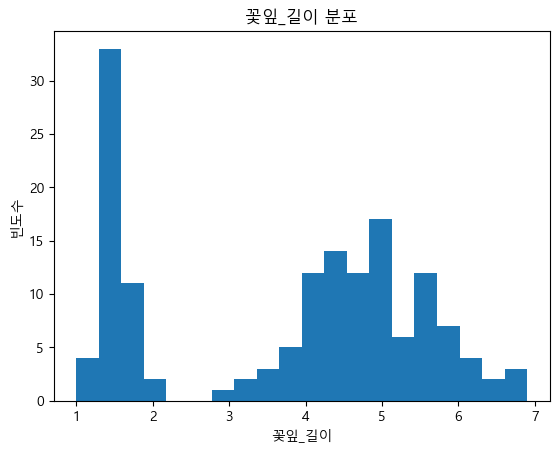

In [9]:
df['꽃잎_길이'].plot(kind='hist', bins=20)
plt.title('꽃잎_길이 분포')
plt.xlabel('꽃잎_길이')
plt.ylabel('빈도수')
plt.show()

<Axes: xlabel='꽃잎_길이', ylabel='Count'>

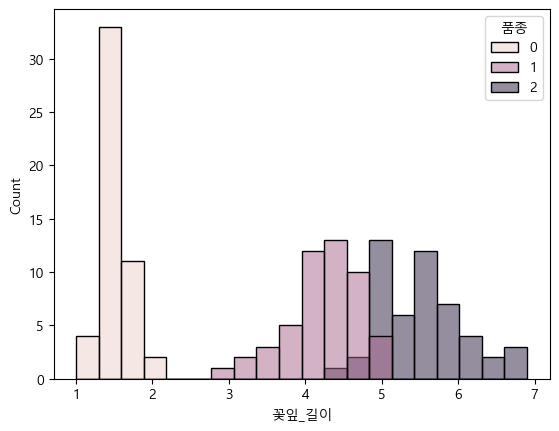

In [12]:
sns.histplot(data=df, x='꽃잎_길이', bins=20, hue='품종')


## 데이터 시각화
### 시각화가 왜 중요한가?
> 숫자만 보면 패턴을 파악하기 어렵습니다.  
> 그래프로 시각화하면 **데이터의 분포, 관계, 특성**을 한눈에 파악할 수 있습니다.

### 이번에 그릴 그래프들
1. **히스토그램**: 각 특성(수치)의 분포 확인
2. **박스플롯**: 품종별 특성 분포 및 이상값 확인
3. **산점도**: 두 특성 간의 관계 확인
4. **히트맵**: 특성 간 상관관계 확인

문제: 품종 별 꽃잎_길이 평균값

In [13]:
df.groupby('품종')['꽃잎_길이'].mean()

품종
0    1.464
1    4.260
2    5.552
Name: 꽃잎_길이, dtype: float64

<Axes: xlabel='품종', ylabel='꽃잎_길이'>

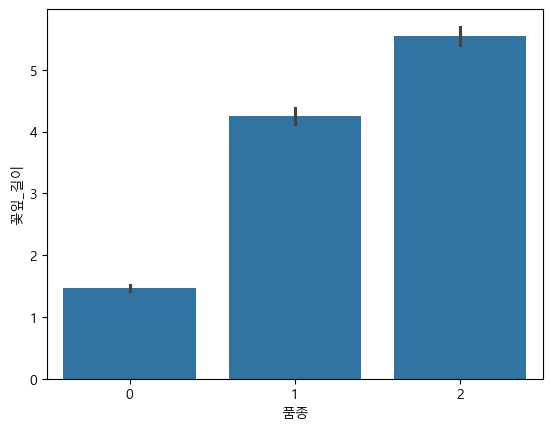

In [14]:
sns.barplot(data=df, x='품종', y='꽃잎_길이')

문제: 품종 별 꽃잎_길이 중앙값

In [15]:
df.groupby('품종')['꽃잎_길이'].median()

품종
0    1.50
1    4.35
2    5.55
Name: 꽃잎_길이, dtype: float64

<Axes: xlabel='품종', ylabel='꽃잎_길이'>

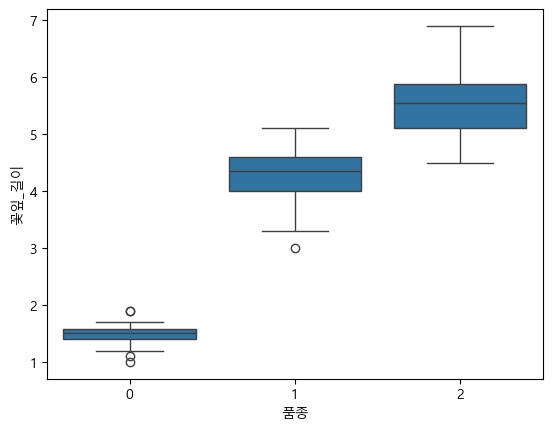

In [16]:
sns.boxplot(data=df, x='품종', y='꽃잎_길이')

문제: 꽃잎의 길이와 너비의 관계 산점도

<Axes: xlabel='꽃잎_길이', ylabel='꽃잎_너비'>

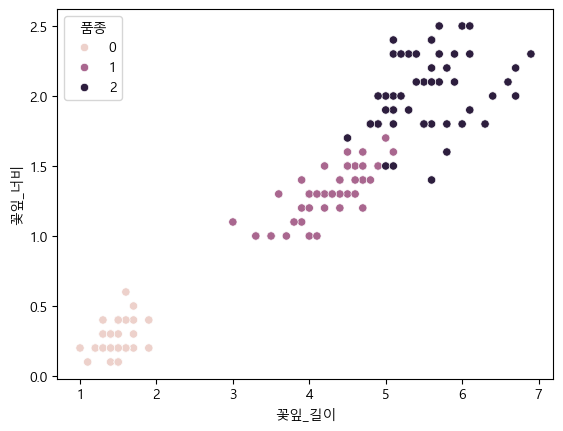

In [17]:
sns.scatterplot(data=df, x='꽃잎_길이', y='꽃잎_너비', hue='품종')

### ============================================================
### 상관관계 히트맵
#### 상관계수: 두 변수가 얼마나 관련있는지 나타내는 수치 (-1 ~ +1)
-   +1에 가까울수록: 한 변수가 증가하면 다른 변수도 증가
-   -1에 가까울수록: 한 변수가 증가하면 다른 변수는 감소
-   0에 가까울수록: 두 변수 간 관계가 없음
### ============================================================


In [18]:
df.columns

Index(['꽃받침_길이', '꽃받침_너비', '꽃잎_길이', '꽃잎_너비', '품종'], dtype='object')

In [24]:
corr = df[['꽃받침_길이', '꽃받침_너비', '꽃잎_길이', '꽃잎_너비']].corr()
corr

,꽃받침_길이,꽃받침_너비,꽃잎_길이,꽃잎_너비
꽃받침_길이,1.000000,-0.109369,0.871754,0.817954
꽃받침_너비,-0.109369,1.000000,-0.420516,-0.356544
꽃잎_길이,0.871754,-0.420516,1.000000,0.962757
꽃잎_너비,0.817954,-0.356544,0.962757,1.000000


<Axes: >

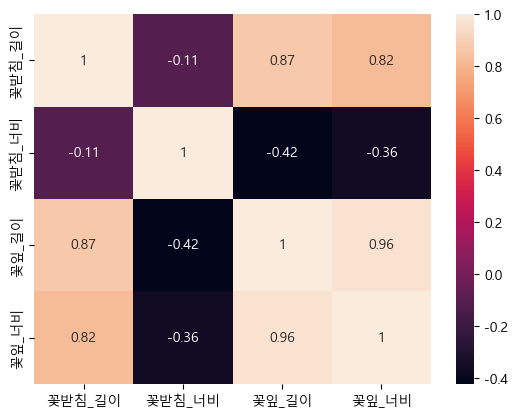

In [26]:
sns.heatmap(corr, annot=True)

##  머신러닝 전처리 (Preprocessing)

### 전처리 단계
1. **특성(X)과 레이블, 타겟 (y) 분리** - 입력과 정답 나누기
2. **훈련/테스트 세트 분할** - 학습용 데이터와 평가용 데이터 나누기


### 훈련/테스트 세트 분할의 이유
```
전체 데이터 (150개)
    ├── 훈련 세트 (Train Set): 112개 (75%) ← 모델을 학습시키는 데이터
    └── 테스트 세트 (Test Set):  38개 (25%) ← 모델을 평가하는 데이터

 중요: 테스트 세트는 절대 학습에 사용하지 않습니다!
    (시험 문제를 미리 알면 실력을 제대로 평가할 수 없는 것과 같음)
```

In [27]:
df.columns

Index(['꽃받침_길이', '꽃받침_너비', '꽃잎_길이', '꽃잎_너비', '품종'], dtype='object')

In [28]:
X=df[['꽃받침_길이', '꽃받침_너비', '꽃잎_길이', '꽃잎_너비']]

In [29]:
y=df['품종']

In [31]:
X_train, X_test, y_train, y_test  =  train_test_split(X, y, test_size=0.25, random_state=42)

### KNN (K-Nearest Neighbors, K-최근접 이웃)
```
원리: "비슷한 것끼리 뭉친다"
새로운 데이터가 들어오면, 가장 가까운 K개의 이웃을 찾아 
그 이웃들의 다수결로 분류합니다.

예: K=3일 때, 가장 가까운 3개 이웃이 [Setosa, Setosa, Versicolor]이면
      → Setosa로 분류 (2:1로 다수결)

### KNeighborsClassifier()함수사용하여 학습모델(머신)을 만들고 knn으로 지정
- https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
knn.predict(X_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

In [40]:
y_test

73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
110    2
12     0
36     0
9      0
19     0
56     1
104    2
69     1
55     1
132    2
29     0
127    2
26     0
128    2
131    2
145    2
108    2
143    2
45     0
30     0
22     0
15     0
65     1
11     0
42     0
146    2
51     1
27     0
Name: 품종, dtype: int64

In [41]:
knn.score(X_test, y_test)

1.0

문제 : 학습된 머신 knn을 이용하여 새로운 관측값 [5, 2.9, 1, 0.2] 의 품종을 예측하세요

In [43]:
knn.predict([[5, 2.9, 1, 0.2]])

array([0])

여러분 오늘은 미세먼지 OPEN API 사용 복습과 머신러닝에 대하여 처음으로 공부한 시간이었어요    
머신러닝은 처음이라 어려운 개념들도 많았으리라 생각됩니다       
하지만 앞으로 우리는 계속 연습해 나갈거라 잘 이해할 수 있을테니 걱정하지 마시고    
오늘은 이러한 용어들이 있구나 경험하는 시간이 되었다면 충분합니다        
이제는 기말프로젝트로 어떠한 것을 할 것인가 서서히 생각하는 시간을 가져주세요     
주제는 자유이며 데이터분석과 기계학습을 포함하게 됩니다    
데이터 선택이 어려운 친구는 수업에서 다루었던 것을 확장해서 해도 충분합니다       
끝으로 아래 빈 셀에 이번 주에는 어떻게 공부하셨는 지 여러분의 이야기를 저와 공유해주세요!!

In [ ]:
이번주에는 처음으로 붓꽃 데이터를 통해 머신러닝의 개념을 접해볼 수 있어서 매우 좋았습니다.
컴퓨터가 데이터의 패턴을 스스로 학습해 품종을 분류해 낸다는 원리가 신기했습니다.
아직 용어들이 낯설고 어렵지만, 앞으로 반복 학습을 통해 제 것으로 만들어가겠습니다